# Run-down Benchtests For configurations in PMCXCL

In [8]:
# Imports
import math
import numpy as np
import scipy as sp
import pmcxcl
import matplotlib.pyplot as plt
import copy

# I. Import Tested Matrix

In [9]:
# Import IO and Path
# Path Variables:
repo_path = "/Users/caoze/Documents/GitHub/Photon-Transport-Simulation/"     # Replace with repository path
export_address = "output/mcxcl/"
access_address = "data/media_label/"

# Helpers:
def output_address(subfolder="data/", repository=repo_path):
    out_path = f"{repository}{subfolder}"
    return out_path

def modified_output_address(filename, tag = "flux"):
    name_part = filename.split("_")[0]
    new_name = f"{name_part}_{tag}.npy"         # Tag File Type
    return new_name

In [12]:
# Accessing Matrix
filename = "test_label.mat"
access_path = f"{repo_path}{access_address}{filename}"
print("Accessing: " + access_path)

# Open file:
content = sp.io.loadmat(access_path)
print(content.keys())

Accessing: /Users/caoze/Documents/GitHub/Photon-Transport-Simulation/data/media_label/test_label.mat
dict_keys(['__header__', '__version__', '__globals__', 'ri_label'])


(150, 150)


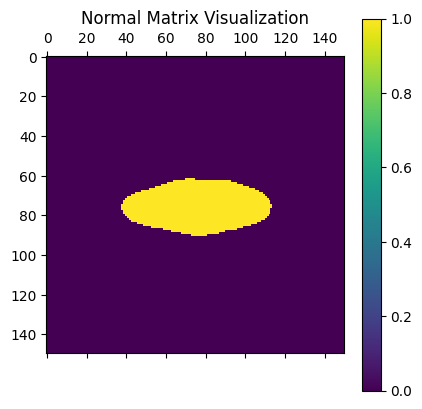

In [13]:
# Retrieve Matrix
extract = content['ri_label']
pix_num = [extract.shape[1], extract.shape[0]]
print(extract.shape)

# Verify
plt.matshow(extract) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Normal Matrix Visualization")
plt.show() 

# Prepare Sample

Gel cutoff at 90
Values:  [0 1 2]
Dimentsions:  (150, 150)


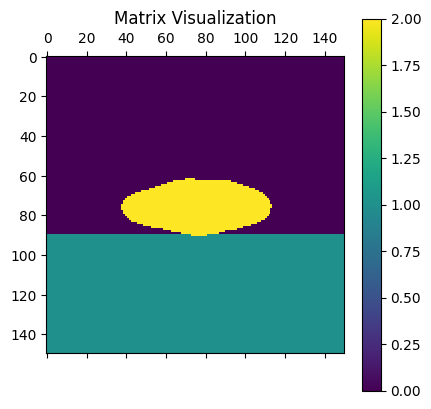

In [14]:
# # RI Matrix labeling(0 = air, 1 = gel, 2 = body):
# Padding Labels
air = 0
gel = 1

# Helper
def pad(arr, air, gel, cutoff, depth):

    # Above cutoff
    rows_air = arr[:cutoff, :]
    rows_air[rows_air == 0] = air
    arr[:cutoff, :] = rows_air

    # Below cutoff
    rows_gel = arr[cutoff:depth, :]
    rows_gel[rows_gel == 0] = gel
    arr[cutoff:depth, :] = rows_gel

    return arr
def find_cutoff(array):
    # Find the lowest point on z where the cell is still present, this is the gel line makesure there are consistently 3 consecutive points in the row.
    cell_level= []
    for i in range(array.shape[0]):
        if np.sum(array[i,:]) > 0: # If there are any non-zero values in the row, it means the cell is present
            if i > 1 and np.sum(array[i-1,:]) > 0 and np.sum(array[i-2,:]) > 0: # Check for 3 consecutive rows
                cell_level.append(i)
    return max(cell_level) # The lowest point where the cell is still present

# Padding
cell_mat = np.where(extract > 0, 2, 0)         # Flag Cell Body

cutoff = find_cutoff(cell_mat)
print(f"Gel cutoff at {cutoff}")

padded= pad(cell_mat, air, gel, cutoff, pix_num[1])
print("Values: ", np.unique(padded))
print("Dimentsions: ", padded.shape)

# Visualized
plt.matshow(cell_mat) 
plt.colorbar() # Creates a colorbar for the plot
plt.title("Matrix Visualization")
plt.show() 

In [15]:
# Build Volume
pad = 100
vol = np.repeat(padded[:, :, np.newaxis], pad,axis=2) # Repeat the 2D matrix along the z-axis to create a 3D volume

print("Volume saved:", vol.shape)
print("Tissue labels:", np.unique(vol))

Volume saved: (150, 150, 100)
Tissue labels: [0 1 2]


# II. Configuration and Run For Benchmark Testing

In [ ]:
# Built in bench testing
bench = {}
bench["cube60"] = {
    "nphoton": 1000000,
    "vol": np.ones([60, 60, 60], dtype="uint8"),
    "tstart": 0,
    "tend": 5e-9,
    "tstep": 5e-9,
    "srcpos": [29, 29, 0],
    "srcdir": [0, 0, 1],
    "prop": [[0, 0, 1, 1], [0.005, 1, 0.01, 1.37], [0.002, 5, 0.9, 1]],
    "isreflect": 0,
    "seed": 1648335518,
    "session": "cube60",
    "detpos": [[29, 19, 0, 1], [29, 39, 0, 1], [19, 29, 0, 1], [39, 29, 0, 1]],
    "issrcfrom0": 1,
}

bench["cube60b"] = copy.deepcopy(bench["cube60"])
bench["cube60b"]["isreflect"] = 1

bench["cube60planar"] = copy.deepcopy(bench["cube60b"])
bench["cube60planar"]["srctype"] = "planar"
bench["cube60planar"]["srcpos"] = [10, 10, -10]
bench["cube60planar"]["srcparam1"] = [40, 0, 0, 0]
bench["cube60planar"]["srcparam2"] = [0, 40, 0, 0]


In [ ]:
# Test-Run the simulation
print("Running MCXCL simulation...")
res = pmcxcl.run(bench["cube60"])
print("Complete!!!")
print(res.keys())

In [ ]:
# Fetch Data
flux = res["flux"]
detp = res["detp"]
print(flux.shape)
print(detp.shape)

In [ ]:
# Slice-Viewing: select a single time
slice = flux[30, :, :, 0]  # shape (4,5)

# Display
plt.imshow(slice, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux")
plt.title(f"Flux at x={30}, t_idx={0}")
plt.show()

# III. Configuration and Run For Tested Configuration Model

In [ ]:
"""
Test Configurations Template
test_cfg = {
    'nphoton': 1000000, 
    'vol':np.ones([60,60,60],dtype='uint8'), 
    'tstart':0, 'tend':5e-9, 'tstep':5e-10,
    'srcpos': [30,30,0], 'srcdir':[0,0,1], 
    'prop':[[0,0,1,1],[0.005,1,0.01,1.37]]}
"""
# Can play with this
test_cfg = {
    'nphoton': 1000000, 
    'vol':np.ones([60,60,60],dtype='uint8'), 
    'tstart':0, 'tend':5e-9, 'tstep':5e-10,
    'srcpos': [30,30,0], 'srcdir':[0,0,1], 
    'prop':[[0,0,1,1],[0.005,1,0.01,1.37]]}

In [ ]:
# Test-Run the simulation
print("Running MCXCL simulation...")
res = pmcxcl.run(test_cfg)
print("Complete!!!")
print(res.keys())

# Fetch Data
flux = res["flux"]
print(flux.shape)

In [ ]:
# Slice-Viewing: select a single time
slice = flux[30, :, :, 0]  # shape (4,5)

# Display
plt.imshow(slice, cmap='hot', interpolation='nearest')
plt.colorbar(label="Flux")
plt.title(f"Flux at x={30}, t_idx={0}")
plt.show()